# Point Patter Analysis in Python

This notebook will demonstrate how to apply methods for Point Patter Analysis using different Python modules. It is based on data from http://insideairbnb.com/, a website that regularly scrapes AirBnB to enable analytics that AirBnB itself does not provide. 

###### Load some libraries

In [31]:
import pandas as pd # tabular data in Python for data manipulation and analysis
import geopandas as gpd # extension to Pandas to work with geospatial data
import urllib.request # download from the web
import os.path # work with the local file system
from shapely.geometry import Point # basic functions to work with vector geometries and construct points from airbnb
import matplotlib as mpl # plotting
from matplotlib import pyplot as plt # some matplotlib convenience functions

# make figures larger
plt.rcParams['figure.figsize'] = [16, 16]  # to make figures larger or any size we wish

#### Download some data

Let's download data for the Copenhagen area at the end of May 2020 and end of June 2016 from http://insideairbnb.com/get-the-data.html. The goal will be to check whether we can see some kind of development in the AirBnB listings and their spatial distribution.

For both of the files, we will first check whether they have been downloaded already; if not, download them. Start with 2020:

In [32]:
fname = 'AirBnB-CPH-30-05-2020.csv' # the file will be saved under this name locally on your computer.
url   = 'http://data.insideairbnb.com/denmark/hovedstaden/copenhagen/2020-05-30/visualisations/listings.csv'
if(os.path.isfile(fname)): # this is basically copy pasted webadress of the fili from 2020 dataset
    print(fname,'already downloaded.')
else:
    print('Downloading', fname)
    urllib.request.urlretrieve(url, fname)
    print('Done', fname)  # last lines of coide basically retrieves the file from url and then saves with 
                         # the name spefifyed above

AirBnB-CPH-30-05-2020.csv already downloaded.


Repeat for 2016:

In [33]:
fname = 'AirBnB-CPH-28-06-2016.csv'
url   = 'http://data.insideairbnb.com/denmark/hovedstaden/copenhagen/2016-06-28/visualisations/listings.csv'

if(os.path.isfile(fname)):
    print(fname,'already downloaded.')
else:
    print('Downloading', fname)
    urllib.request.urlretrieve(url, fname)
    print('Done', fname)

AirBnB-CPH-28-06-2016.csv already downloaded.


#### Load the data

We'll load the data as a geodataframe first to do some filtering, to do so we load them in to notebook using pandas library as we already mentioed before.

In [34]:
fname = 'AirBnB-CPH-30-05-2020.csv'

df = pd.read_csv(fname) # pandas has a function to read a csv file as a table
listings20 = gpd.GeoDataFrame(df, # geopandas turn the data into geodataframe.df using the 2020 dataset, i.e. 
                              # to add extra coloumn in to the table that containes geometry or coordinates for 
                               # each point 
    crs=('epsg:4326'), # set the coordinate reference system to WGS84 lat/lon
    geometry=[Point(xy) for xy in zip(df.longitude, df.latitude)]) # construct the point geometries or object from 
                                                                   # lat/lon

listings20.head() # and then load just first couple of lines to see what was created and how it looks like, 
                 # and what type of information do we have downloaded from the airbnb website

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,geometry
0,6983,Copenhagen 'N Livin',16774,Simon,NaN,Nrrebro,55.68798,12.54571,Private room,368,2,168,2019-07-19,1.28,1,90,POINT (12.54571 55.68798)
1,26057,Lovely house - most attractive area,109777,Kari,NaN,Indre By,55.69163,12.57459,Entire home/apt,2398,3,50,2019-12-14,0.63,1,358,POINT (12.57459 55.69163)
2,26473,City Centre Townhouse Sleeps 1-12 persons,112210,Oliver,NaN,Indre By,55.67590,12.57698,Entire home/apt,3095,3,293,2020-03-02,2.50,1,169,POINT (12.57698 55.6759)
3,29118,Best Location in Cool Istedgade,125230,Nana,NaN,Vesterbro-Kongens Enghave,55.67069,12.55430,Entire home/apt,797,7,22,2019-08-02,0.18,1,8,POINT (12.5543 55.67069)
4,29618,Artsy and familyfriendly home in lovely Copenh...,127577,Simon And Anna,NaN,sterbro,55.69375,12.56945,Entire home/apt,855,7,90,2017-06-03,0.75,1,0,POINT (12.56945 55.69375)


<Axes: >

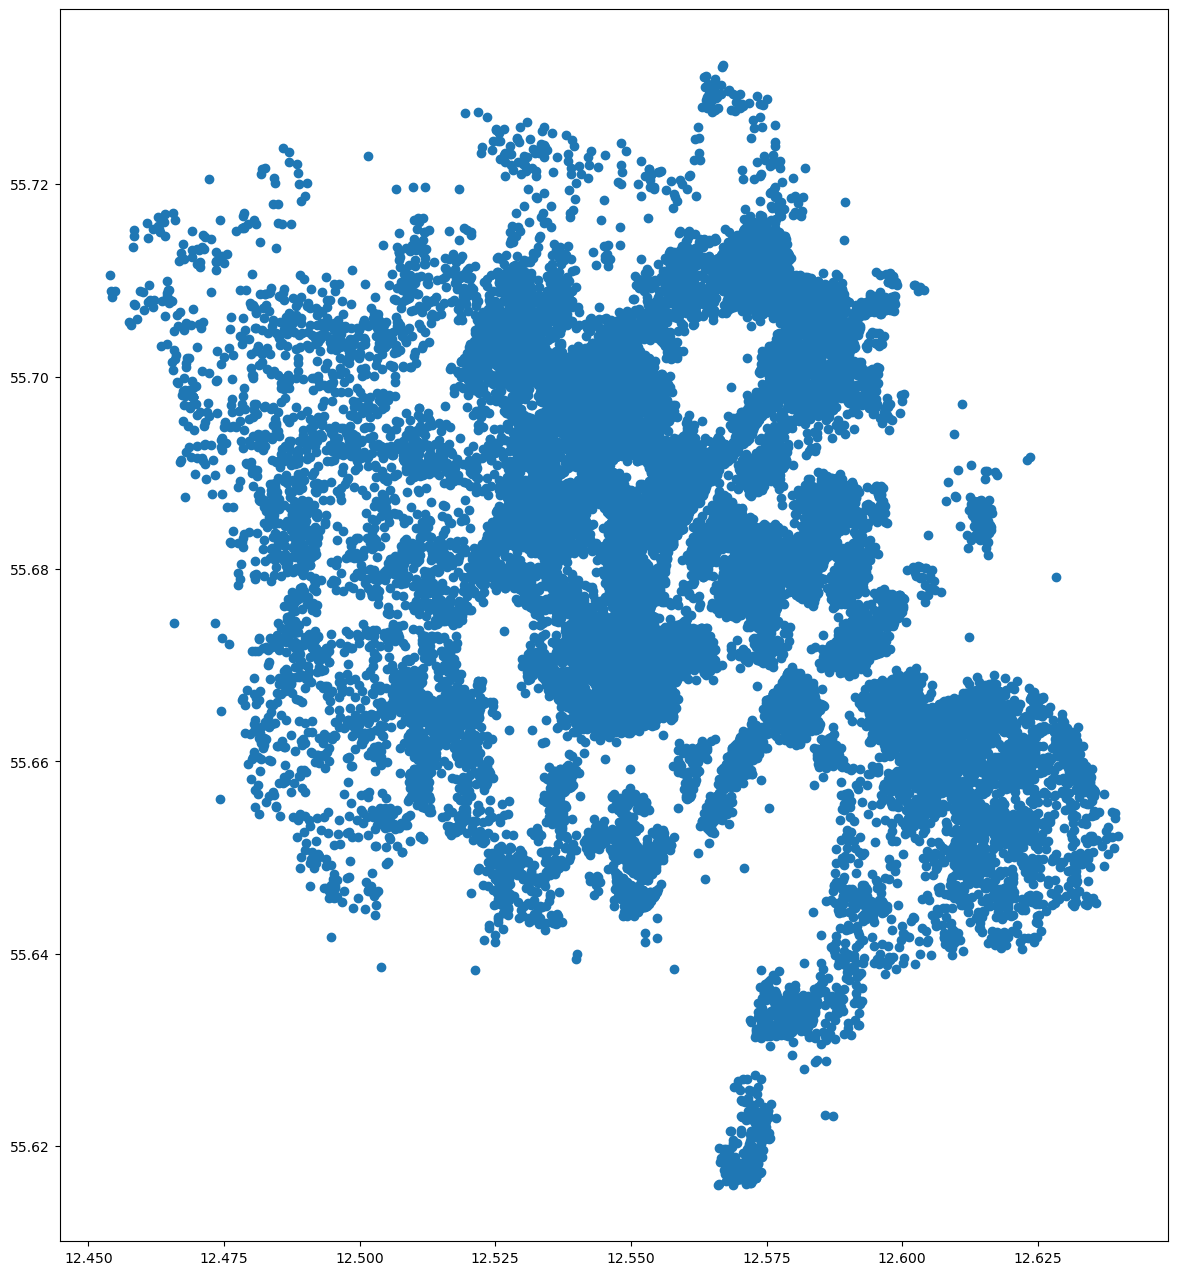

In [35]:
listings20.plot()

Repeat for 2016:

In [36]:
fname = 'AirBnB-CPH-28-06-2016.csv'

df = pd.read_csv(fname)
listings16 = gpd.GeoDataFrame(df,
    crs=('epsg:4326'), # set the coordinate reference system to WGS84 lat/lon
    geometry=[Point(xy) for xy in zip(df.longitude, df.latitude)]) # construct the point geometries from lat/lon

listings16.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,geometry
0,13105840,"En-suite room with private bathroom, Frederiks...",45850390,Olivia,NaN,Frederiksberg,55.688972,12.530683,Private room,1599,7,0,NaN,NaN,1,364,POINT (12.53068 55.68897)
1,8518014,Bright cosy apartment,36509172,Louise,NaN,Frederiksberg,55.684235,12.533837,Entire home/apt,486,2,0,NaN,NaN,1,0,POINT (12.53384 55.68423)
2,7175046,Lejlighed m. have på Frederiksberg,37583932,Anne Sophie,NaN,Frederiksberg,55.677427,12.549187,Entire home/apt,1201,7,0,NaN,NaN,1,22,POINT (12.54919 55.67743)
3,2255352,Homy apartment at Frederiksberg,11517071,Jonas Hjortkjær,NaN,Frederiksberg,55.681227,12.524041,Entire home/apt,398,1,0,NaN,NaN,1,0,POINT (12.52404 55.68123)
4,8657830,Lys 130 Kvm 2 sal på Frederiksberg,45495978,Frederik,NaN,Frederiksberg,55.680501,12.525905,Entire home/apt,634,1,1,2015-11-25,0.14,1,0,POINT (12.52591 55.6805)


<Axes: >

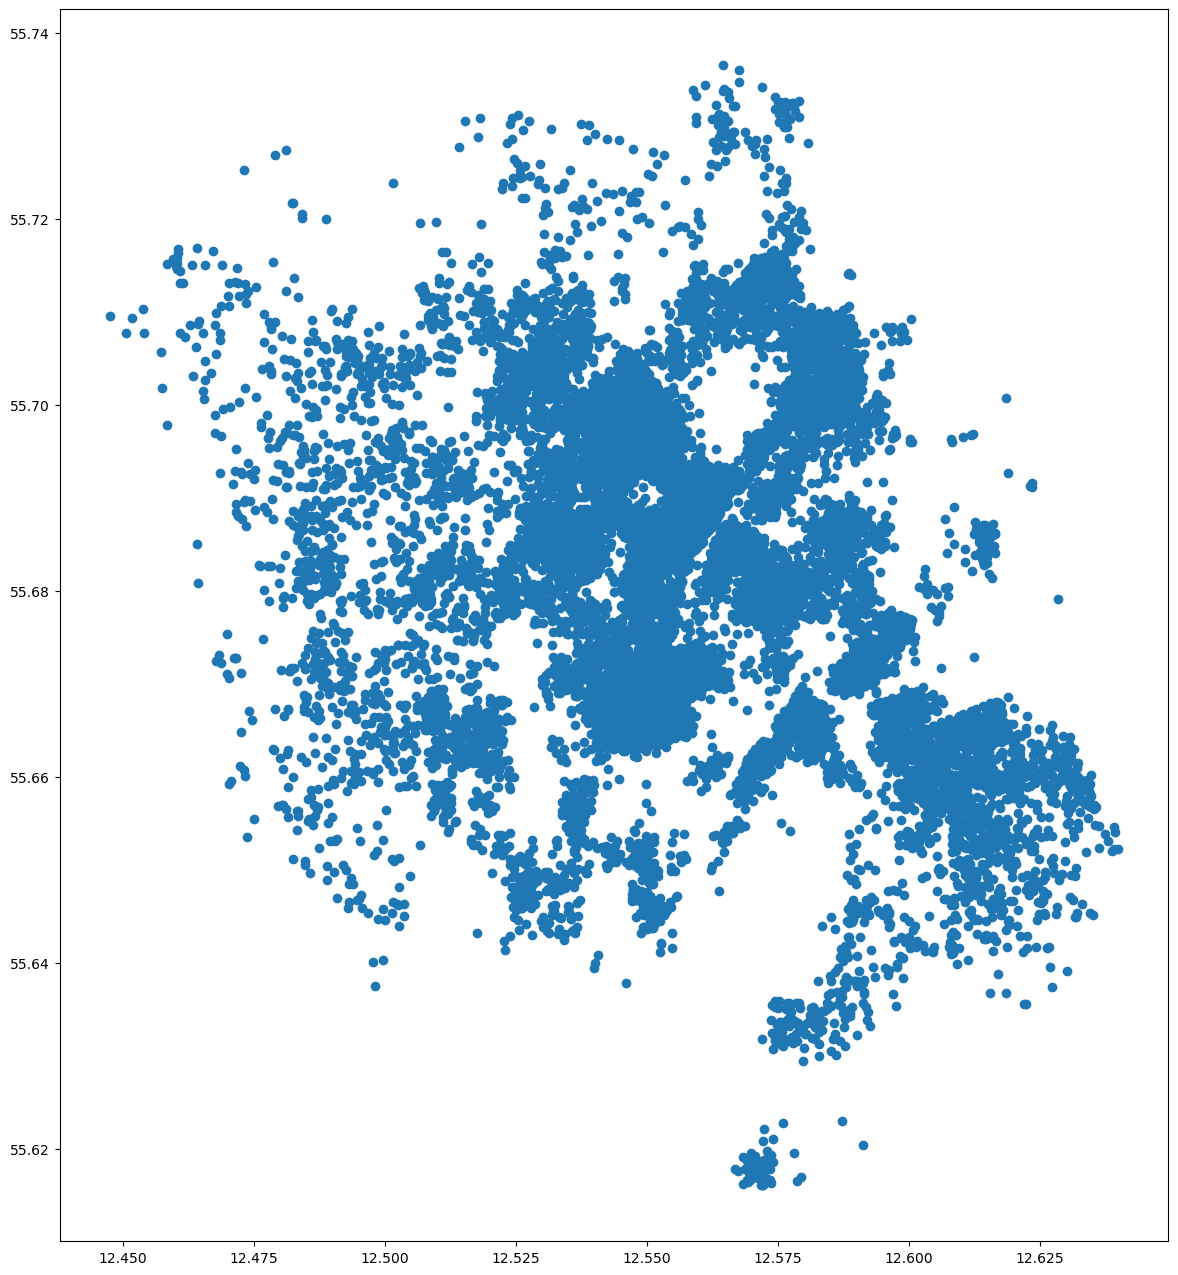

In [37]:
listings16.plot()

Not easy to see any difference between 2020 and 2016, right? That's where point pattern analysis comes in! 

#### Filter data

But first, let's filter the data a bit. We'll only look at listings where the whole place is for rent (not just a room inside):

In [38]:
print(len(listings16)) # how many listings before filtering in 2016?
listings16 = listings16[listings16["room_type"] == "Entire home/apt"] # here we indicate that we are interested in 
                                        # only the listings with the specigic type, i.e. entire home or appartment
print(len(listings16)) # and after we can see how many of them are there
listings16.head()

16178
12940


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,geometry
1,8518014,Bright cosy apartment,36509172,Louise,NaN,Frederiksberg,55.684235,12.533837,Entire home/apt,486,2,0,NaN,NaN,1,0,POINT (12.53384 55.68423)
2,7175046,Lejlighed m. have på Frederiksberg,37583932,Anne Sophie,NaN,Frederiksberg,55.677427,12.549187,Entire home/apt,1201,7,0,NaN,NaN,1,22,POINT (12.54919 55.67743)
3,2255352,Homy apartment at Frederiksberg,11517071,Jonas Hjortkjær,NaN,Frederiksberg,55.681227,12.524041,Entire home/apt,398,1,0,NaN,NaN,1,0,POINT (12.52404 55.68123)
4,8657830,Lys 130 Kvm 2 sal på Frederiksberg,45495978,Frederik,NaN,Frederiksberg,55.680501,12.525905,Entire home/apt,634,1,1,2015-11-25,0.14,1,0,POINT (12.52591 55.6805)
5,5504818,Cosy apartment close to the city,28551835,Christian,NaN,Frederiksberg,55.680627,12.547342,Entire home/apt,702,1,0,NaN,NaN,1,0,POINT (12.54734 55.68063)


Next, we'll remove places with less than 25 reviews - we are only interested in AirBnBs that get booked a lot:

In [39]:
print(len(listings16)) # how many listings before filtering?
listings16 = listings16[listings16["number_of_reviews"] > 25] # only keep the listings that have minimum 25 reviews
print(len(listings16)) # and print how many was before filtering and after applying our filtering option
listings16.head()

12940
802


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,geometry
42,862862,Wonderfull apartment with balconies,498378,Finn,NaN,Frederiksberg,55.678961,12.530923,Entire home/apt,805,2,45,2016-06-22,1.16,1,279,POINT (12.53092 55.67896)
47,560719,Fantastic flat with a balcony,2757155,Hanne,NaN,Frederiksberg,55.684558,12.539078,Entire home/apt,905,5,39,2016-06-11,0.84,1,294,POINT (12.53908 55.68456)
108,7847482,Apartment in lovely Frederiksberg,17595934,Ask,NaN,Frederiksberg,55.680462,12.545279,Entire home/apt,805,1,53,2016-06-12,5.06,2,150,POINT (12.54528 55.68046)
122,1197829,Lovely flat in trendy part of CPH,6543443,Marie,NaN,Frederiksberg,55.674838,12.551711,Entire home/apt,905,1,32,2016-05-29,0.89,2,152,POINT (12.55171 55.67484)
125,3254142,Beautiful 3 rooms apartment in CPH,16458045,Christina,NaN,Frederiksberg,55.681087,12.556603,Entire home/apt,1381,1,27,2016-06-13,1.17,1,355,POINT (12.5566 55.68109)


Let's do the same for 2020 (in one go):

In [40]:
print(len(listings20)) # how many listings before filtering?
listings20 = listings20[(listings20["room_type"] == "Entire home/apt") & 
                        (listings20["number_of_reviews"] > 25)]
print(len(listings20))
listings20.head()

28196
3057


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,geometry
1,26057,Lovely house - most attractive area,109777,Kari,NaN,Indre By,55.69163,12.57459,Entire home/apt,2398,3,50,2019-12-14,0.63,1,358,POINT (12.57459 55.69163)
2,26473,City Centre Townhouse Sleeps 1-12 persons,112210,Oliver,NaN,Indre By,55.67590,12.57698,Entire home/apt,3095,3,293,2020-03-02,2.50,1,169,POINT (12.57698 55.6759)
4,29618,Artsy and familyfriendly home in lovely Copenh...,127577,Simon And Anna,NaN,sterbro,55.69375,12.56945,Entire home/apt,855,7,90,2017-06-03,0.75,1,0,POINT (12.56945 55.69375)
6,32379,1668 ft2 artist flat on Vesterbro,140105,Lise,NaN,Vesterbro-Kongens Enghave,55.67297,12.55327,Entire home/apt,1079,3,73,2019-08-17,0.61,1,6,POINT (12.55327 55.67297)
8,33850,Modern Vesterbro Apartmnt w/Balcony,146201,Caroline,NaN,Vesterbro-Kongens Enghave,55.66980,12.55619,Entire home/apt,1196,5,40,2018-09-25,0.33,1,0,POINT (12.55619 55.6698)


### Reproject

A lot of what we are going to do is going to be based on Euclidian distance. Since lat/lon coordinates are spherical (i.e. they are in degrees, describing a position on a sphere), we'll project the coordinates to a planar coordinate reference system – [UTM Zone 32 North](https://epsg.io/25832), specifically:

In [41]:
print(listings16.crs) # here we tell to project both files using the suitable coordinate system for Copenhagen
print(listings20.crs)

listings16 = listings16.to_crs(epsg=25832) # this done in geopandas by using to crs, it basically transforms old 
                                            # coordinate refference sytem in to the new one 
listings20 = listings20.to_crs(epsg=25832)

print(listings16.crs)
print(listings20.crs)

epsg:4326
epsg:4326
EPSG:25832
EPSG:25832


In [42]:
listings16.head() # and if you compare the coordinated in bellow table to the coordinated to the above table, 
                    # you will notice difference

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,geometry
42,862862,Wonderfull apartment with balconies,498378,Finn,NaN,Frederiksberg,55.678961,12.530923,Entire home/apt,805,2,45,2016-06-22,1.16,1,279,POINT (721986.745 6176001.899)
47,560719,Fantastic flat with a balcony,2757155,Hanne,NaN,Frederiksberg,55.684558,12.539078,Entire home/apt,905,5,39,2016-06-11,0.84,1,294,POINT (722467.472 6176650.485)
108,7847482,Apartment in lovely Frederiksberg,17595934,Ask,NaN,Frederiksberg,55.680462,12.545279,Entire home/apt,805,1,53,2016-06-12,5.06,2,150,POINT (722880.348 6176214.922)
122,1197829,Lovely flat in trendy part of CPH,6543443,Marie,NaN,Frederiksberg,55.674838,12.551711,Entire home/apt,905,1,32,2016-05-29,0.89,2,152,POINT (723316.589 6175610.086)
125,3254142,Beautiful 3 rooms apartment in CPH,16458045,Christina,NaN,Frederiksberg,55.681087,12.556603,Entire home/apt,1381,1,27,2016-06-13,1.17,1,355,POINT (723588.377 6176320.84)


Notice how the numbers in the geometry column are now different? They have been transformed to UTM32N!

# Mean centre

In Geopandas, we can extract the x and y components of the coordinates like so:

In [43]:
listings16.geometry.x.mean() # form the listings of 2016 we take x coordinate mean, just one coordinate

np.float64(723939.2452120162)

So we can easily take the means and turn them into a new point:

In [44]:
mean_centre_16 = Point((listings16.geometry.x.mean(), listings16.geometry.y.mean())) # then we use above coordinate 
                                                                        # to construct X and Y mean for both files  
mean_centre_20 = Point((listings20.geometry.x.mean(), listings20.geometry.y.mean())) # here we do not ask to print 
                                                                            # anything but we use them later

Let's show them on a map to see if the mean center has shiffted over 4 years. First, load the outline of Copenhagen municipality as a reference:

CPH.geojson already downloaded.


<Axes: >

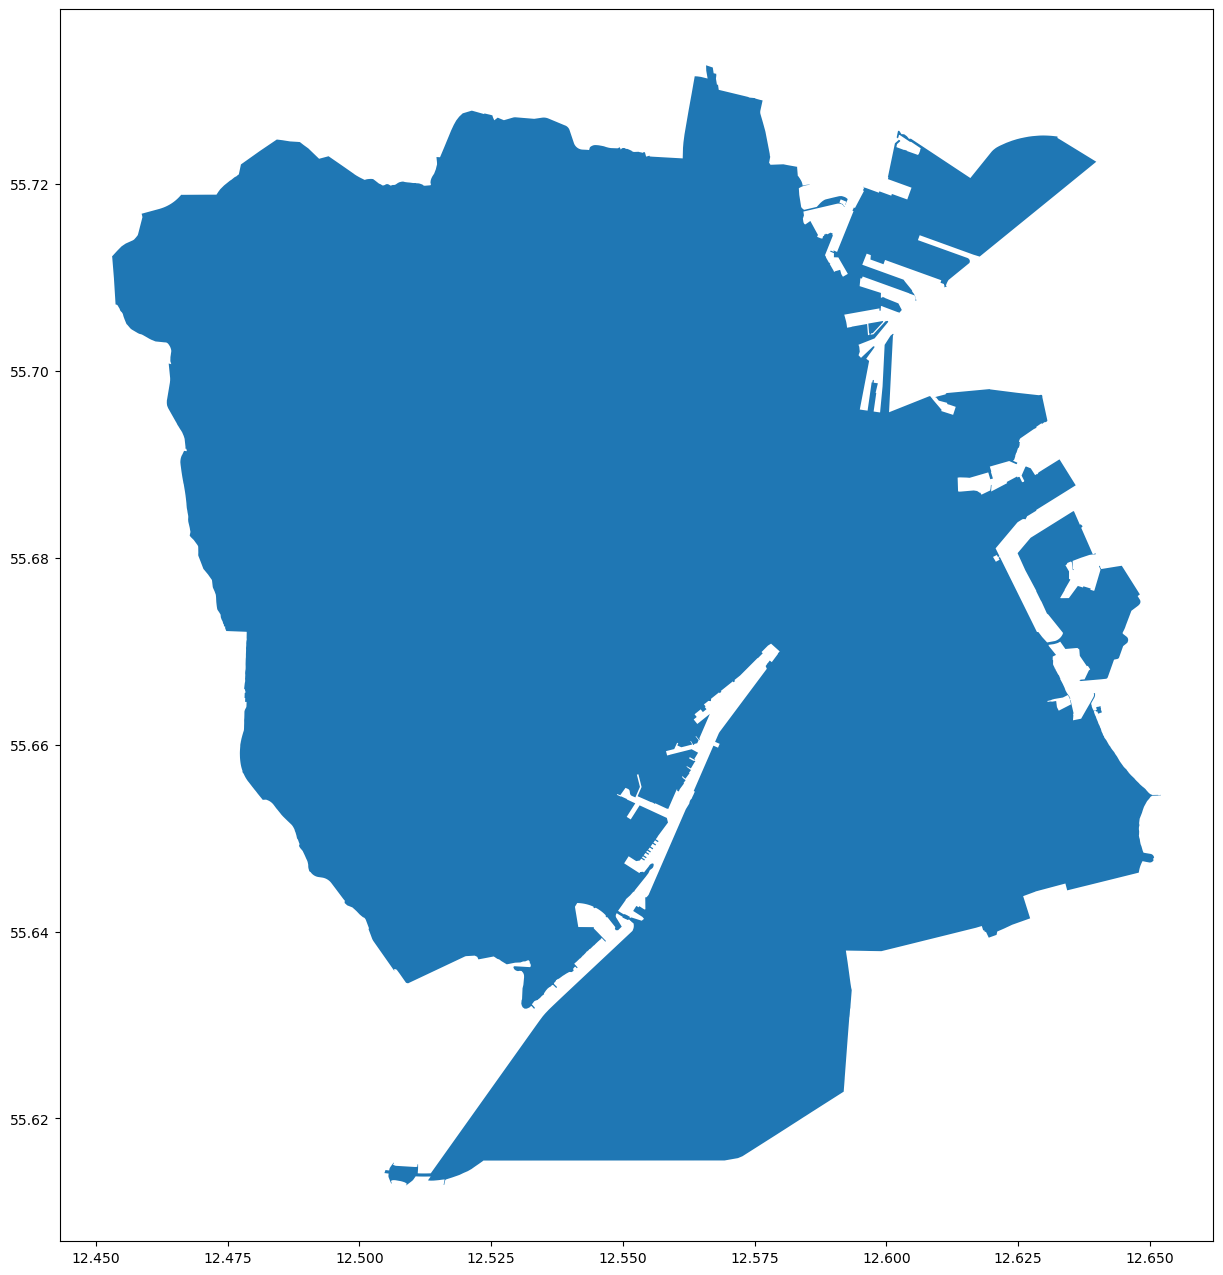

In [45]:
fname = 'CPH.geojson' # I created the geojson file from the shp file downloaded from the website, just CPH outline
url   = 'http://carsten.io/CPH.geojson' # then it it is uploaded to a personal website 

if(os.path.isfile(fname)):
    print(fname,'already downloaded.') # and here we cheske agin if it is already downloaded, and if not then 
                                        # start downloading or retriving
else:
    print('Downloading', fname)
    urllib.request.urlretrieve(url, fname)
    print('Done', fname)

cph = gpd.read_file(fname) # after download read it as geopandas dataframe and plot the map
cph.plot()

Also project this one to UTM32N:

In [46]:
cph = cph.to_crs(epsg=25832) # similar to airbnb data we have to reproject it in to the similar projection
cph.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Denmark - onshore and offshore; Germany - onshore and offshore; Italy - onshore and offshore; Norway including Svalbard - onshore and offshore; Spain - offshore.
- bounds: (6.0, 36.53, 12.01, 84.01)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Plotting is easier when we turn the mean centres into Geodataframes (here we have to make two mean centers within the copenhagen area by turning both points in to the  geodataframes):

In [47]:
mean_centre_16_gdf = gpd.GeoDataFrame(crs=('epsg:25832'), geometry=[mean_centre_16]) # here we make the new 
                         # gedataframe in utm zone/epsg:25832 with a geometry of mean center
mean_centre_20_gdf = gpd.GeoDataFrame(crs=('epsg:25832'), geometry=[mean_centre_20])

Btw, this is one way to make a simlple map with multiple layers with Geopandas and Matplotlib:

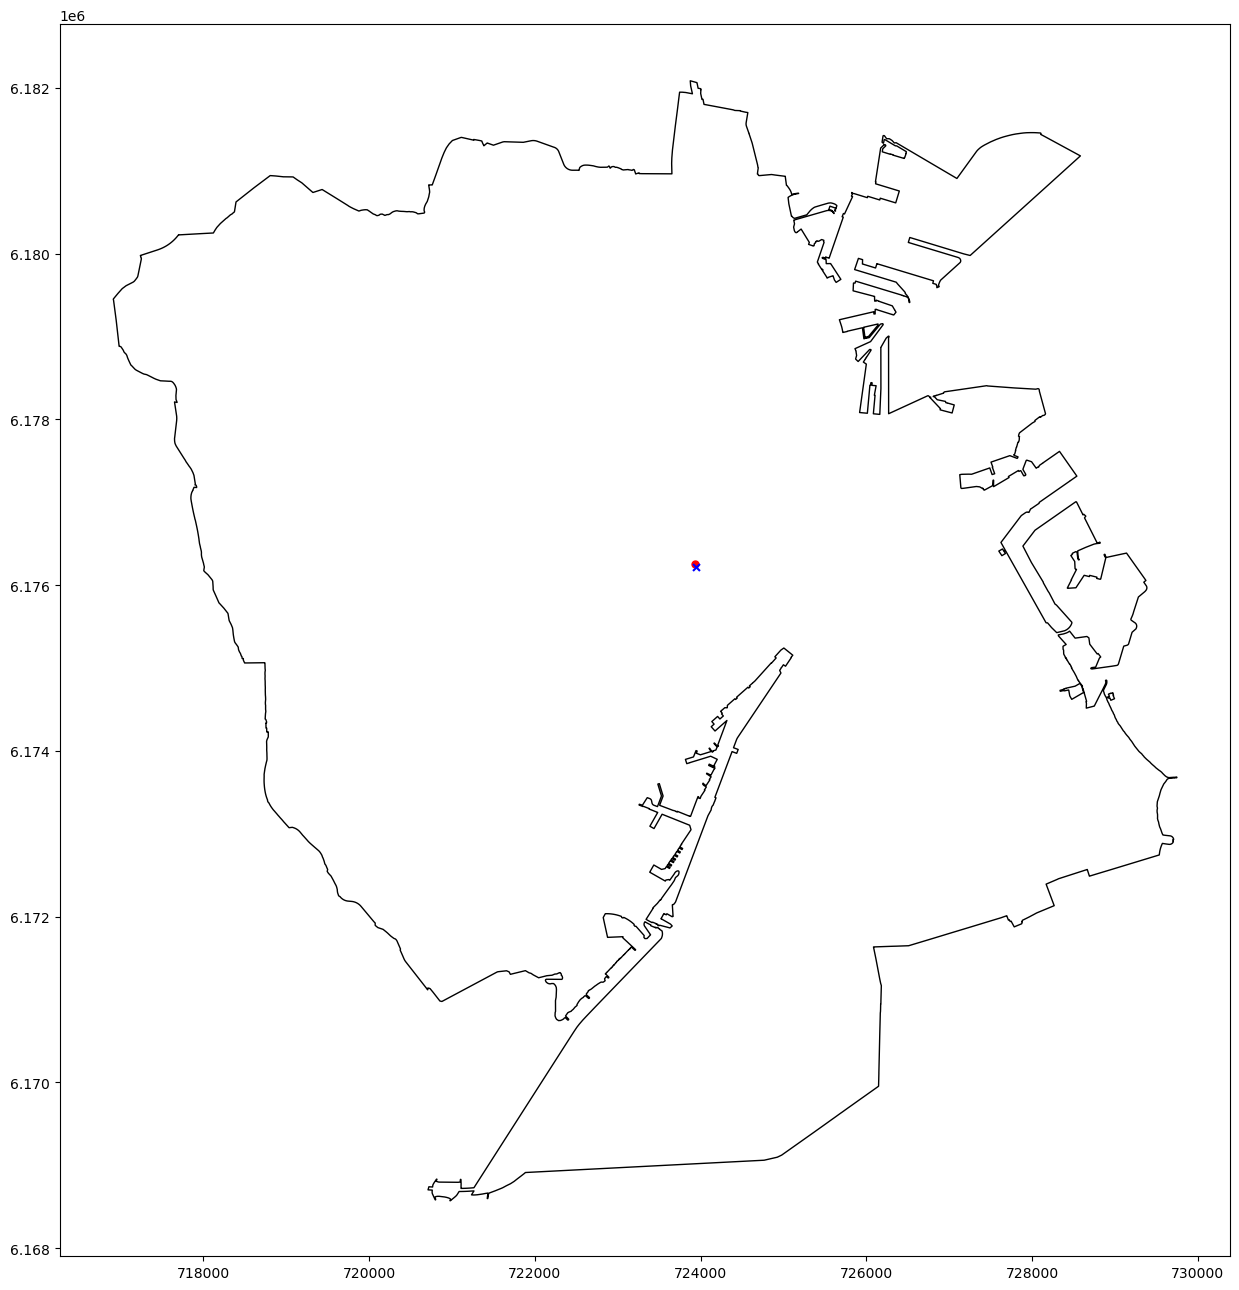

In [48]:
base = cph.plot(color='white', edgecolor='black') # then we plot CPH file in white with black outline
mean_centre_16_gdf.plot(ax=base, marker='o', color='red', markersize=25); # plot mean center of 2016 as O in size 
                                            # 25 with red color on the existing plot
mean_centre_20_gdf.plot(ax=base, marker='x', color='blue', markersize=25); # plot mean center of 2020 as X in size 
                                            # 25 with blue color on the existing plot

Not very useful. Let's check out whether the AirBnBs are more concentrated in the center in 2020:

# Standard distance (exercice)

Task: In your group, come up with a Python implementation of standard distance. Use the [Geopandas documentation](https://geopandas.org/reference.html).

In [49]:
listings16.distance(mean_centre_16).mean() # your code goes here, calculate the standard distance 
                                            # from the mean center
    # calculate the mean distance for each point and then compute the mean distance between all the points

np.float64(1981.0686449639509)

### Calculating the Average Distance to the Mean Centre (2016)

This line calculates the **average distance** of all AirBnB listings in 2016 to the mean centre point we computed earlier.  
It is one way of quantifying how **spread out** the listings are in space.  

---

**What does this line do?**

`listings16.distance(mean_centre_16).mean()`  
→ Step by step:  
- `listings16.distance(mean_centre_16)` → computes the distance from each listing (point) to the 2016 mean centre.  
- `.mean()` → takes the average of all those distances.  

The result is a **single number** (measured in meters, since we reprojected to UTM) representing the average distance of listings to the city’s central point of AirBnB activity.  

---

### Why it matters
- This value is essentially the **standard distance radius** for the 2016 dataset.  
- It captures the **spatial dispersion**:  
  - A **smaller number** means listings are clustered more tightly around the mean centre.  
  - A **larger number** means listings are more widely spread across the city.  
- It provides a quantitative baseline that we can compare to other years (e.g., 2020, 2025) to see if AirBnB activity is becoming more centralized or more dispersed over time.  


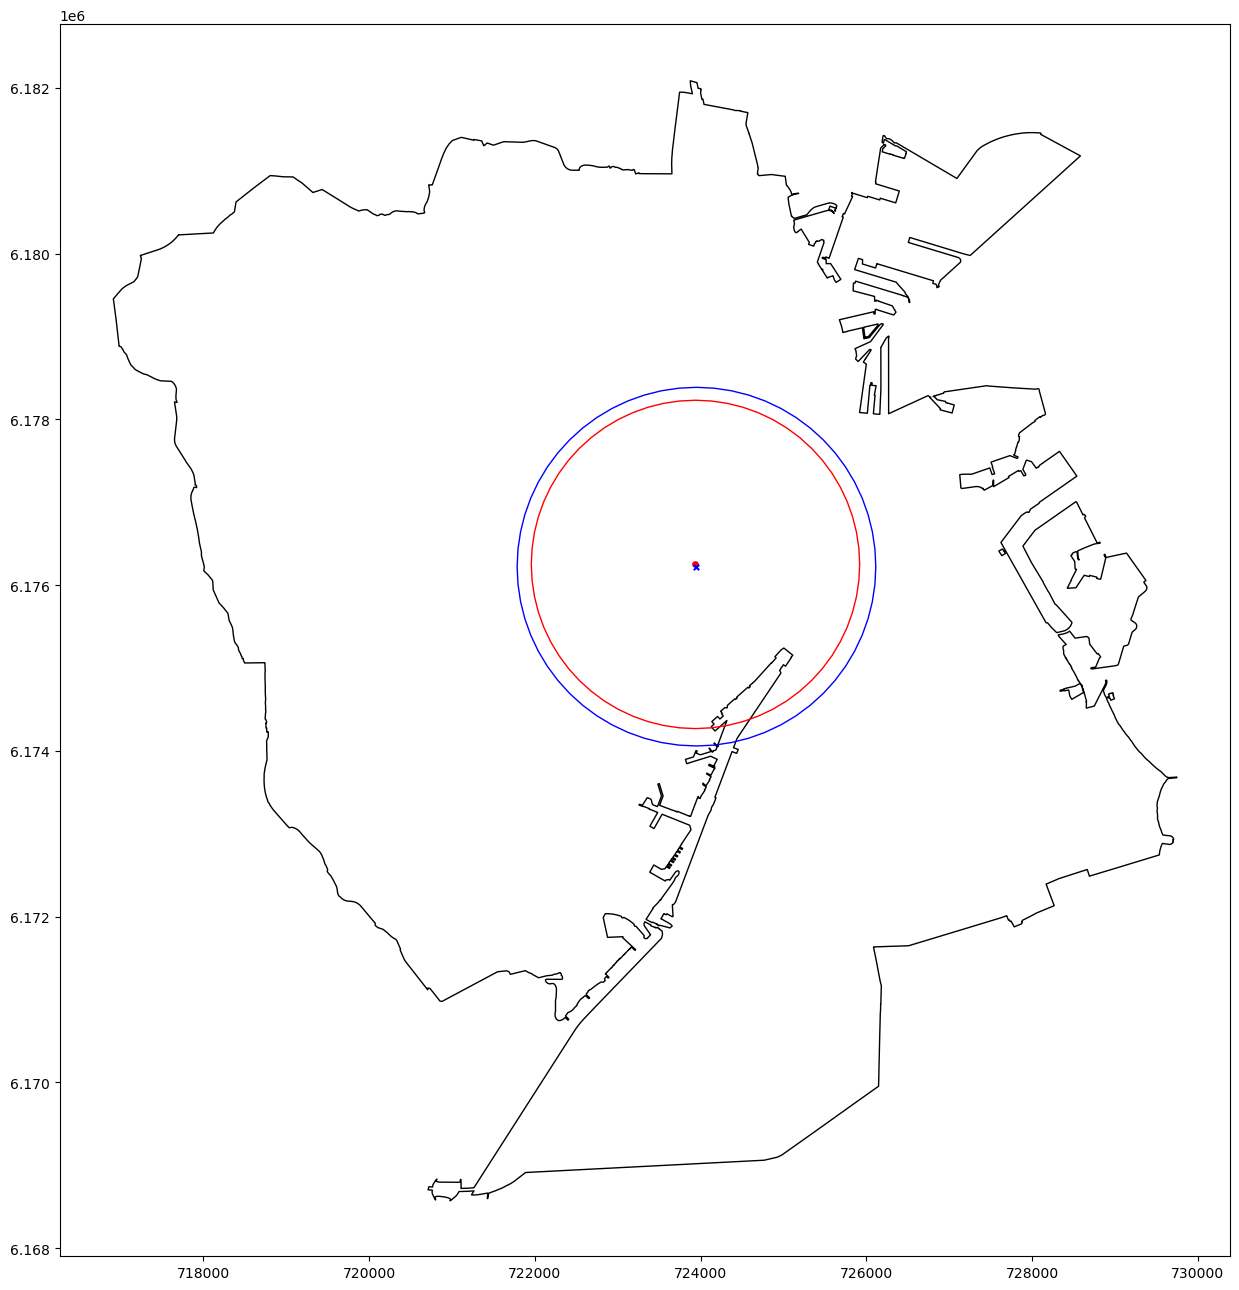

In [50]:
sd16 = listings16.distance(mean_centre_16).mean() # calculate standard distance from mean center in 2016 data
sd20 = listings20.distance(mean_centre_20).mean() # calculate standard distance from mean center in 2020 data
# plot
base = cph.plot(color='white', edgecolor='black') # plot the base map with CPH outline

mean_centre_16_gdf.plot(ax=base, marker='o', color='red', markersize=15); # plot the mean center on top of the CPH

# use the geopandas buffer function to make the summary circle
mean_centre_16_gdf.buffer(sd16).plot(ax=base, edgecolor='red', color='none'); 

# repeat for 2020. also plot:
mean_centre_20_gdf.plot(ax=base, marker='x', color='blue', markersize=15);
mean_centre_20_gdf.buffer(sd20).plot(ax=base, edgecolor='blue', color='none');


# Density - Intensity

We'll calculate the events (AirBnBs, in this case) per aereal unit. To do that, we first need to know how large the study area is:

In [51]:
cph.area # similar to distance we also have area function to calculate CPH area with geopandas, 
             # the number is calculated in mrters and therefore it is large number

0    1.021743e+08
dtype: float64

This is Copenhagen area but if I would have CPH and Frederiksberg separate, we can get the whole area using sum

In [52]:
area_cph = cph.area.sum() # and here we need sum up just in case, although we do not need it
print(area_cph)
area_cph = area_cph / 1000000 # convert to SqKM and we can easily say how many airbnbs are in per sqkm
area_cph

102174278.824508


np.float64(102.174278824508)

Now simply devide the number of listings by that area:

In [53]:
intensity16 = len(listings16) / area_cph # to get intensity we devide number of events on the CPH area
print(intensity16)

intensity20 = len(listings20) / area_cph # we do the same for 2020. 
print(intensity20) # the intensity shows 8 airbnbs per sqkm in 2016 and 30 in 2020

7.849333601634667
29.919467356854334


So the intensity _did_ increase. But how are the events distributed spatially? 

Part V  Let's visualize some histograms:

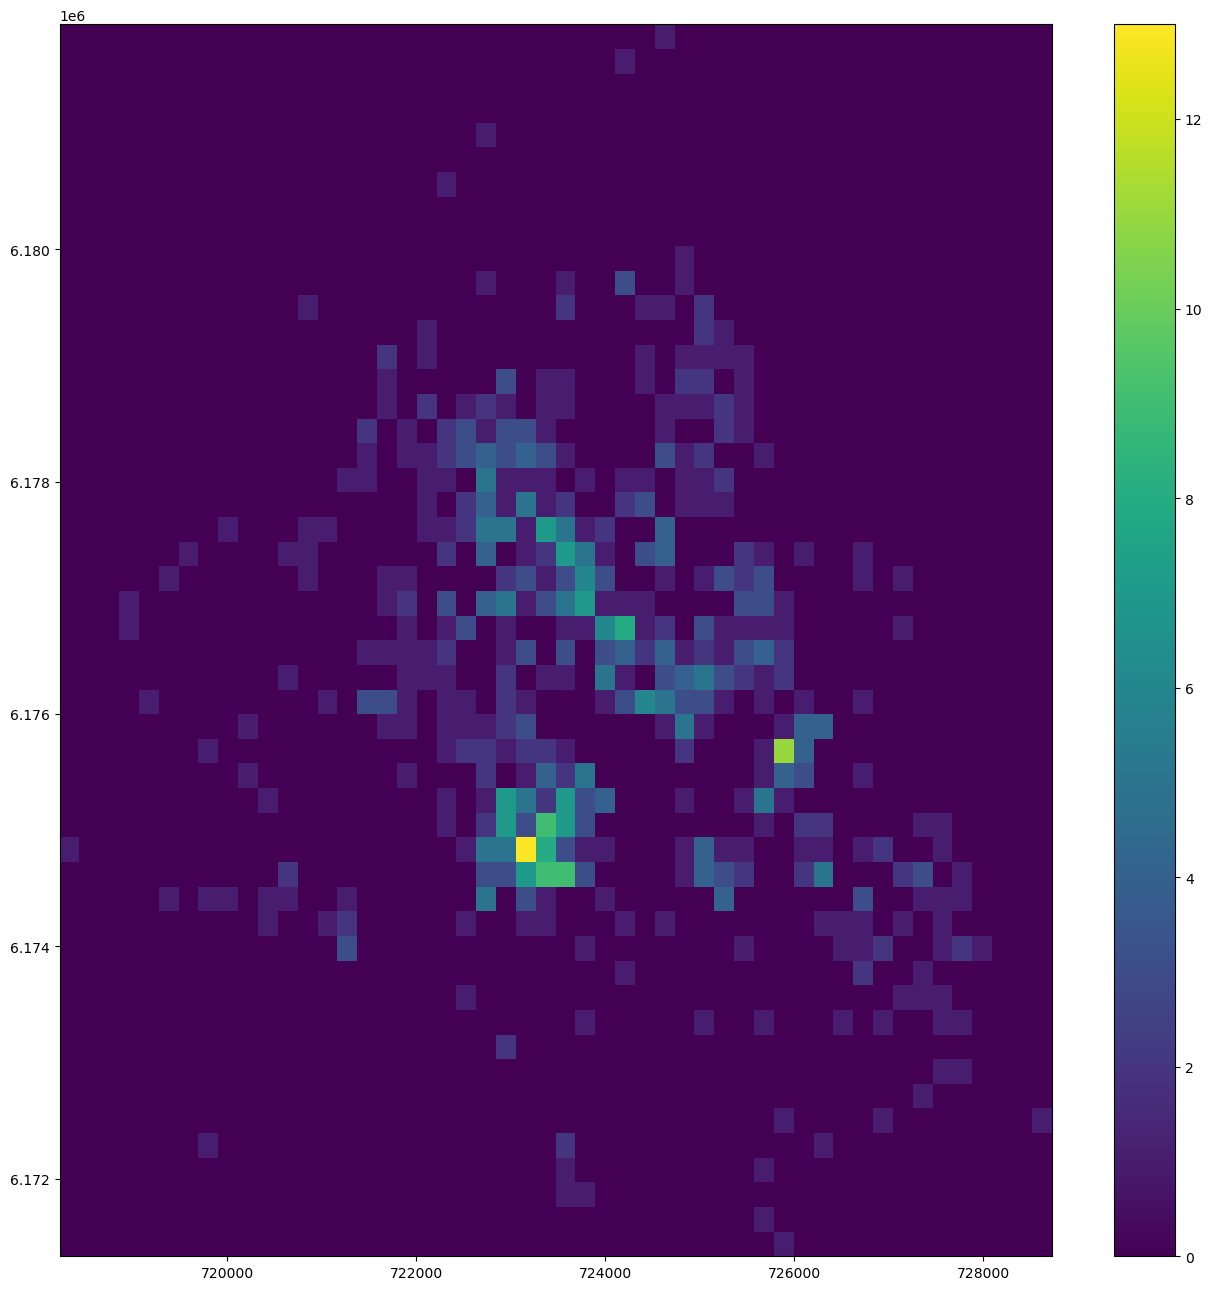

In [54]:
p = plt.hist2d(listings16.geometry.x, listings16.geometry.y, bins=50) # 2D histogram for 2016 revealing the high 
                            # and low number of clusters
plt.colorbar() # we use different colors to represent intensity and then plot
plt.show()

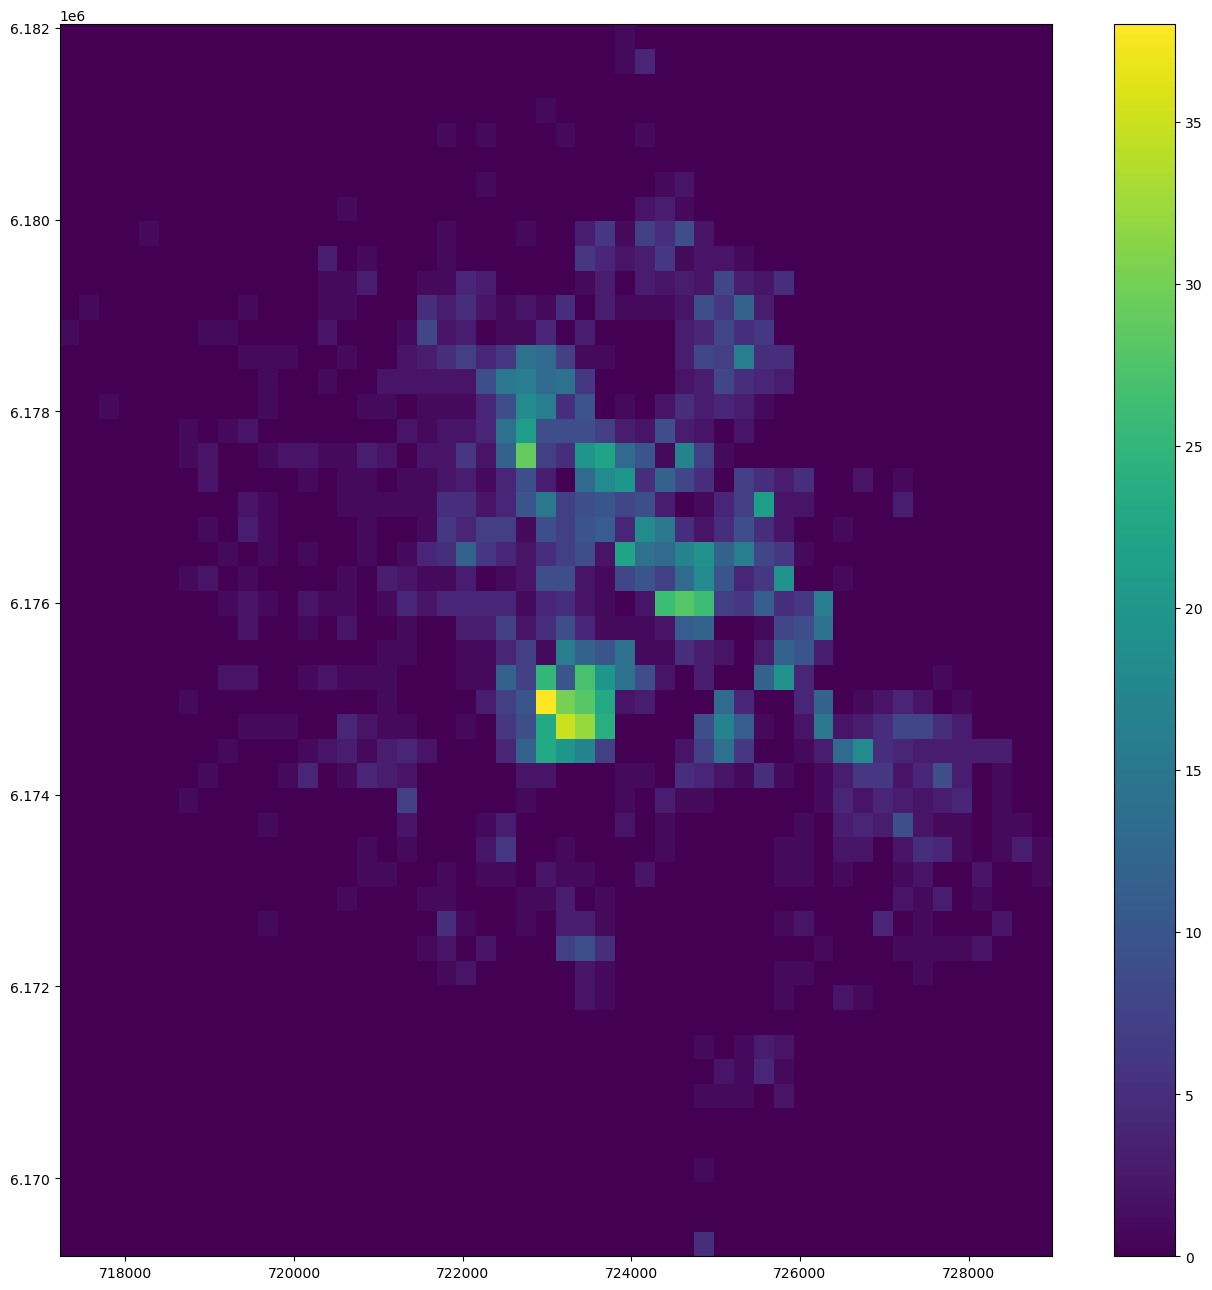

In [55]:
p = plt.hist2d(listings20.geometry.x, listings20.geometry.y, bins=50) # 2D histogram for 2020 dataset revealing the high and low number of clusters
plt.colorbar() # we use different colors to represent intensity and then plot
plt.show()

# Quadrat statistics

Let's check out quadrat-based methods using complete spatial randomness (CSR). We'll only do this for the 2020 data now.

import libpysal as ps # we are importing couple of new libraries, libpysal is basic library that will allow 
                            #to load data among other basic functions
import numpy as np # library for metrics operations
from pointpats import PointPattern, Window, as_window # functions and moduels for point patterns 
from pointpats.distance_statistics import G, F, J, K, L, Genv, Fenv, Jenv, Kenv, Lenv # moduels for point distance 
                                                            # statistics
from pointpats import PoissonPointProcess as csr # we also import functions for poisson distribution
import pointpats.quadrat_statistics as qs # functions to plot quadrat statistics

In [56]:
import numpy as np
import libpysal as ps

# core objects
from pointpats import PointPattern, Window, as_window, PoissonPointProcess as csr

# distance statistics: import the module, not the names
import pointpats.distance_statistics as dst

# pull what exists in your version
K = getattr(dst, "K", None)
G = getattr(dst, "G", None)
F = getattr(dst, "F", None)
J = getattr(dst, "J", None)
L = getattr(dst, "L", None)          # may be None in some versions

# envelope helpers (may not exist in some versions)
Kenv = getattr(dst, "Kenv", None)
Genv = getattr(dst, "Genv", None)
Fenv = getattr(dst, "Fenv", None)
Jenv = getattr(dst, "Jenv", None)
Lenv = getattr(dst, "Lenv", None)


Pointpats needs to create a specifc PointPattern object, which we'll creatre from our AirBnB locations:

In [57]:
airbnb_points_20 = np.array([event for event in zip(listings20.geometry.x, listings20.geometry.y)]) # crate a 
                        # listing for X and Y and zip together X,Y coordinates from that listing 
airbnb_points_20  

array([[ 724658.10349626, 6177551.528639  ],
       [ 724898.56169159, 6175809.9065549 ],
       [ 724323.0656051 , 6177770.65059509],
       ...,
       [ 725752.93324269, 6176273.3776347 ],
       [ 723559.49717596, 6179809.86286633],
       [ 727231.2183926 , 6173563.53734078]], shape=(3057, 2))

Turn into point pattern and plot:

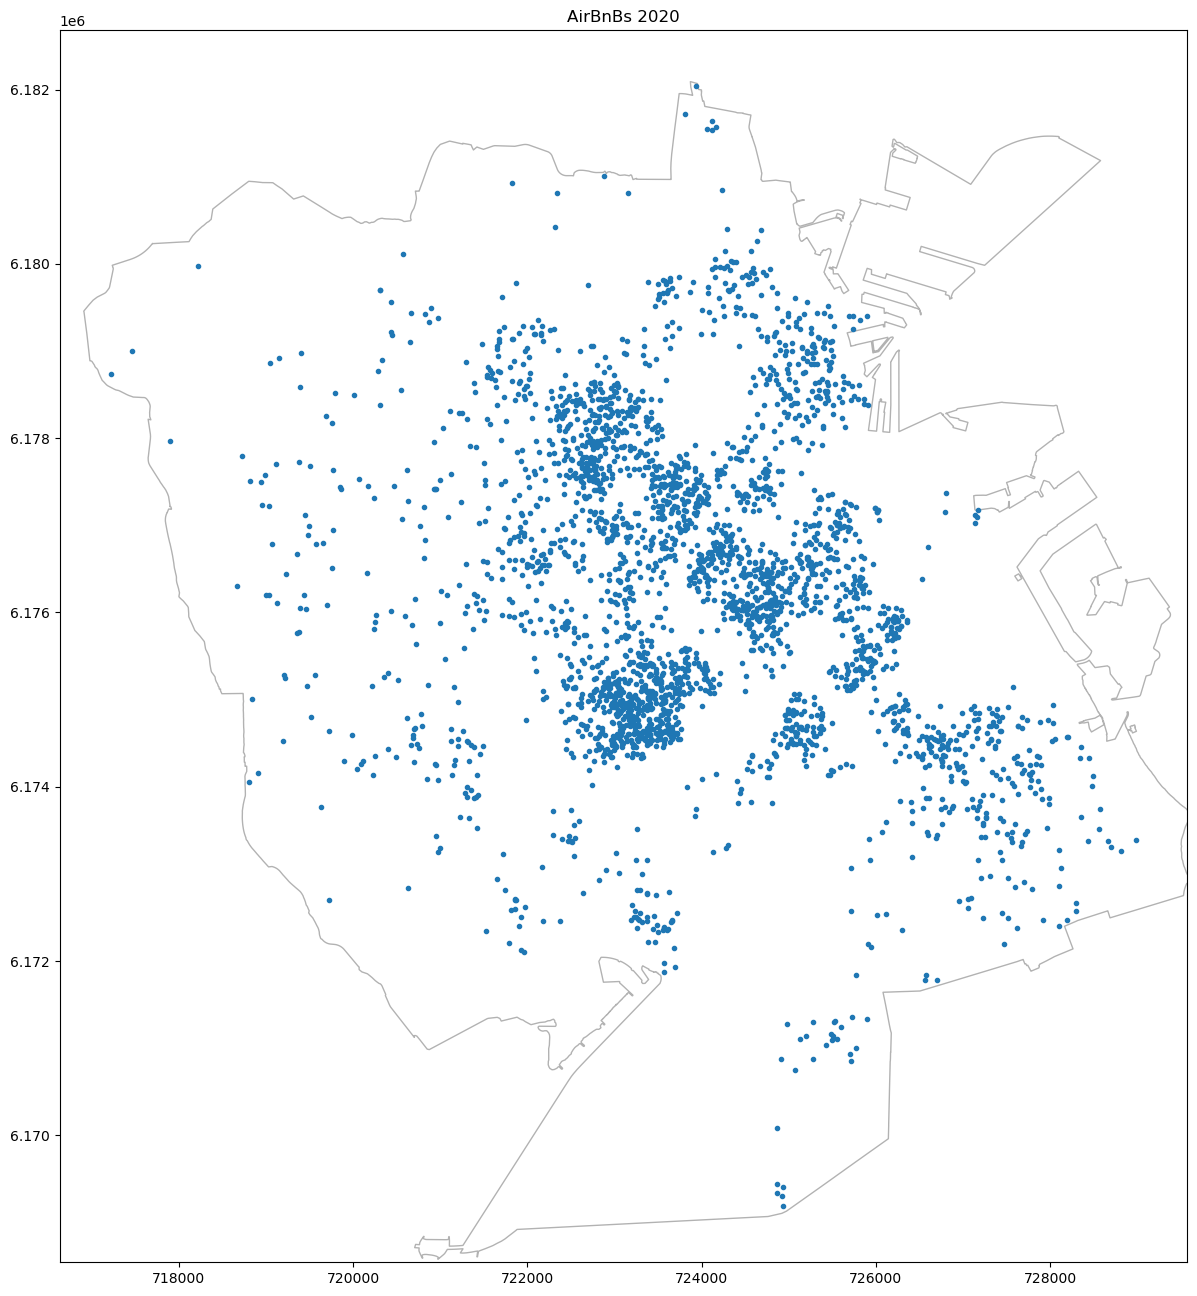

In [59]:
from shapely.geometry import Polygon, MultiPolygon
from libpysal.cg import Polygon as LPSPolygon
from pointpats import PointPattern, as_window
import numpy as np

# 0) Make sure both layers are in meters (EPSG:25832) before distances/windows
# cph = cph.to_crs(epsg=25832)
# listings20 = listings20.to_crs(epsg=25832)

# 1) Dissolve boundary (new API: union_all, not unary_union)
cph_geom = cph.geometry.union_all()   # -> shapely Polygon or MultiPolygon

# 2) If still MultiPolygon, keep the largest piece
if isinstance(cph_geom, MultiPolygon):
    cph_geom = max(cph_geom.geoms, key=lambda g: g.area)

# 3) Convert shapely Polygon -> libpysal Polygon (shell + holes)
shell = list(cph_geom.exterior.coords)
holes = [list(r.coords) for r in cph_geom.interiors]  # can be empty list
lps_poly = LPSPolygon(shell, holes)

# 4) Build a pointpats Window from libpysal polygon
cph_window = as_window(lps_poly)

# 5) (Optional) ensure points are within the window geometry
# listings20 = listings20[listings20.within(cph_geom)]

# 6) Build the (x,y) array for 2020 listings
airbnb_points_20 = np.array(list(zip(listings20.geometry.x, listings20.geometry.y)))

# 7) Create the PointPattern and plot
pp_20 = PointPattern(points=airbnb_points_20, window=cph_window)
pp_20.plot(window=True, title='AirBnBs 2020')

In [60]:
pp_20.summary() # plot a summary of the point patterns object, you can explore or compare the numbers then

Point Pattern
3057 points
Bounding rectangle [(717219.4031683216,6169184.9030276155), (728984.4130160308,6182038.28978539)]
Area of window: 102174278.82450254
Intensity estimate for window: 2.991946735685593e-05
               x             y
0  724658.103496  6.177552e+06
1  724898.561692  6.175810e+06
2  724323.065605  6.177771e+06
3  723425.231985  6.175407e+06
4  723626.845505  6.175064e+06


Now we can generate the quadrat statistic:

<Axes: title={'center': 'Quadrat Count'}>

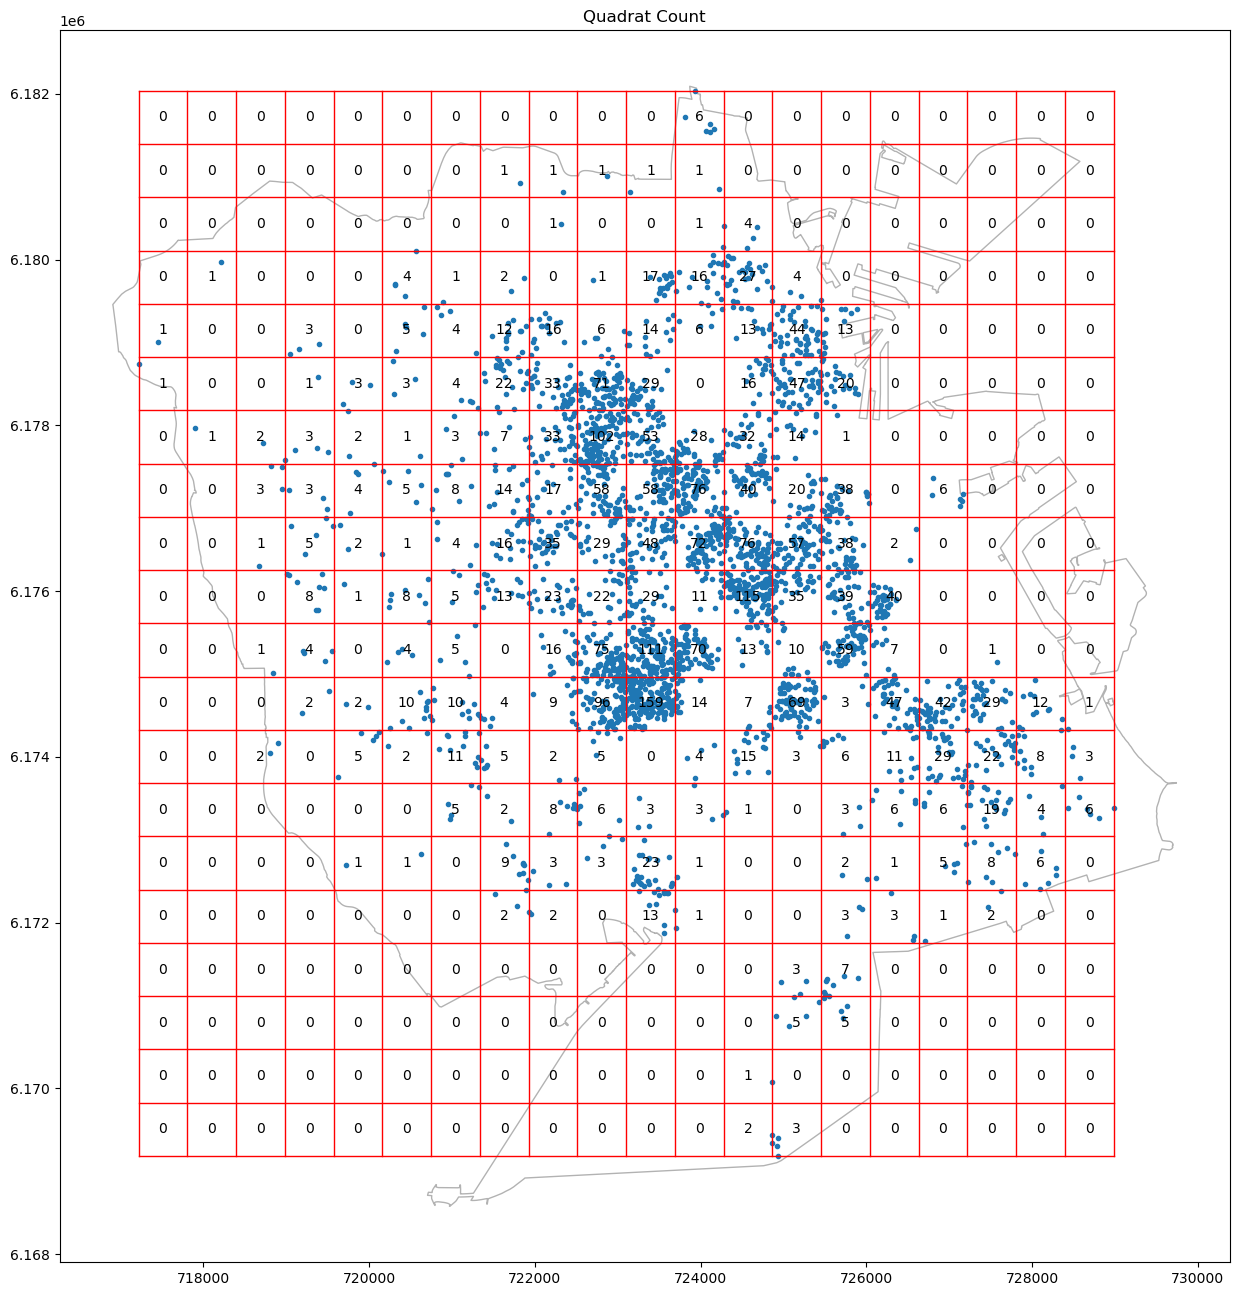

In [62]:
# we wnat quadrat statistics for pp_20 - point 
# patterns 2020 in the shape of rectangles, and make 20 horizontal rows and 20 vertical rows


import pointpats.quadrat_statistics as qs

# Quadrat statistics: divide window into 20 × 20 rectangles
q_r = qs.QStatistic(pp_20, shape="rectangle", nx=20, ny=20)

# Plot quadrats with counts
q_r.plot()


Now we'll compare that with 10 completely random point patterns within our window: 

_(You would normally do more, e.g. 100 or even 1000, but that would take quite long with this number of points.)_

### Let's take a break while this is running.

In [63]:
csr_process = csr(pp_20.window, pp_20.n, 10, asPP=True) # we generate rundome point patterns pp_20.n with the 
            # same intensity within the same window as above using csr function. The number 10 in the code tels 
            # pysal how often to do that.

Let's take a look at one of the randomly generated point patterns:

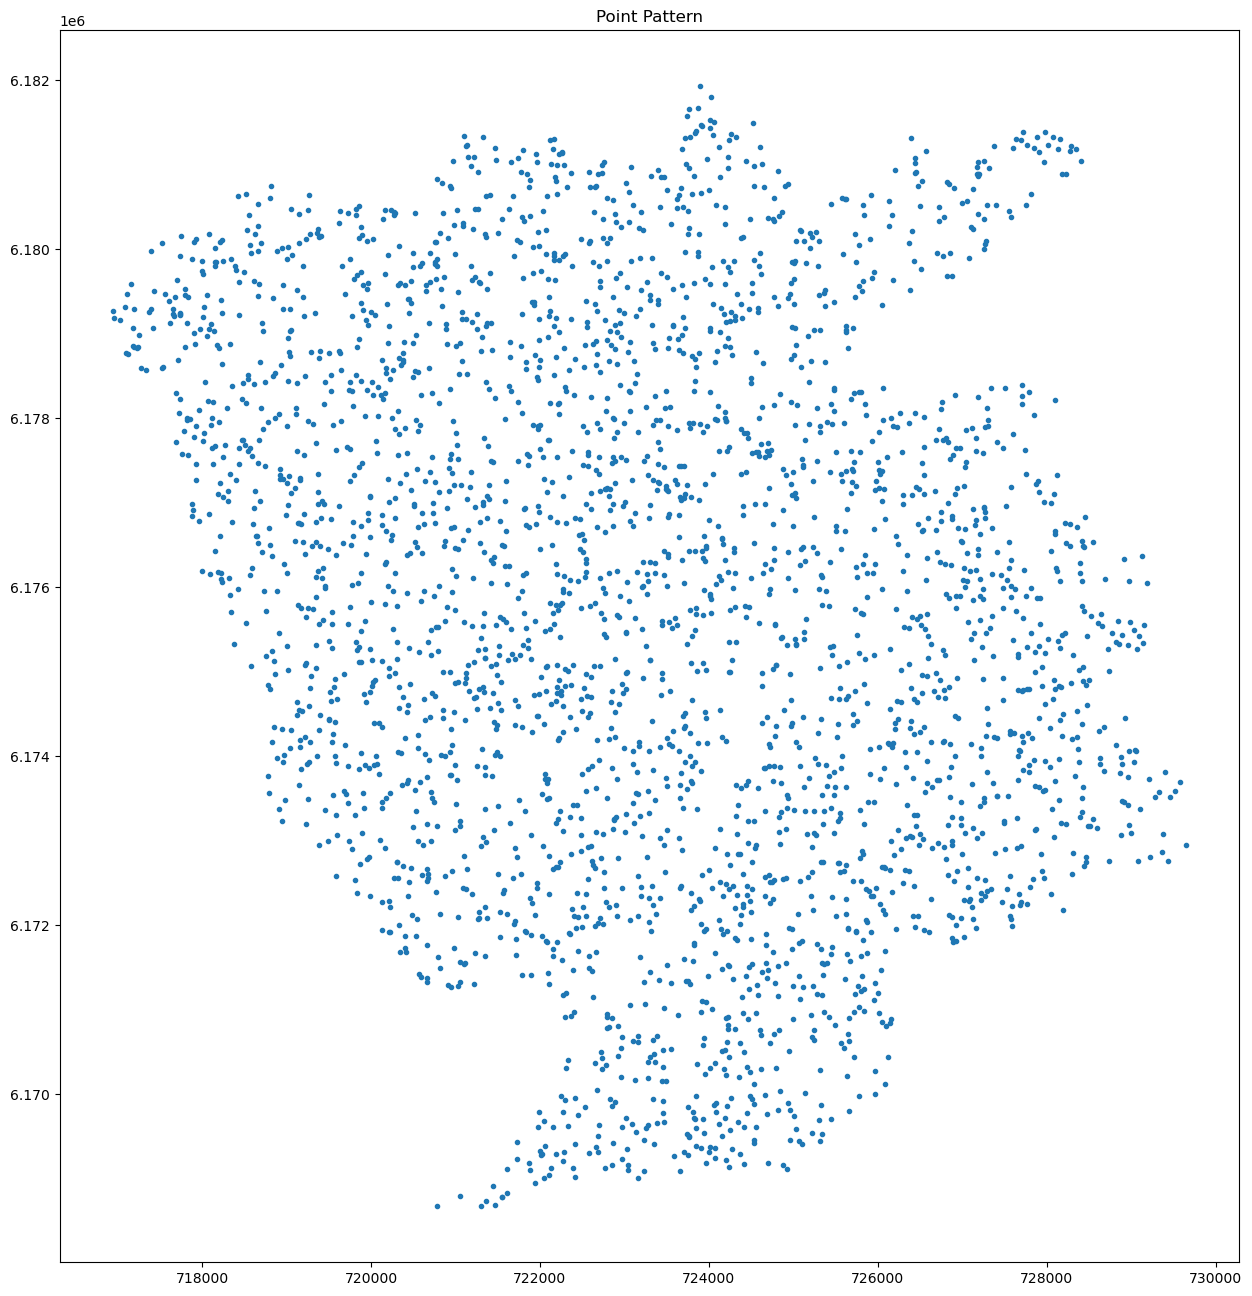

In [64]:
csr_process.realizations[1].plot() # give me the first rundomely generated points and plot

In [65]:
q_r_empirical = qs.QStatistic(pp_20, shape= "rectangle",nx = 20, ny = 20, realizations = csr_process) # use pp_20 
    # data, make rectangles 20x20 and compare that to the realization step that is generated above. 
    # This evaluates if statistically significant way diviades from the rundome point patterns

In [66]:
print(q_r_empirical.chi2) # we test statistics via chi test, if airbnb data is rundomely generated
print(q_r_empirical.chi2_realizations) # we test realization statistics via chi test
print(q_r_empirical.chi2_pvalue) # we test pvalues via chi test. The 10 rundome points gave us a values bellow, 
                                    # and for the observed point patterns we got value of 18319.63....

18319.643768400394
[1972.89859339 2009.01243049 2007.18056919 1994.35754007 1895.43702977
 1990.95551194 1850.94896958 1944.1122015  1959.55217534 2010.58259732]
0.0


We can safely disregard the null hypothesis that the AirBnBs are not clustered.

### Discussion 

**Take 10 minutes in the groups to discuss whether the choice of our window makes sense here. It is the official boundary of Copenhagen (including Frederiksberg), so that should be okay, right?**

## Kernel Density Estimation

Link to interactive KDE tutorial: https://mathisonian.github.io/kde/

In [67]:
import seaborn as sns # we import seaborn to create more visually appealing and informative plots

Documentation for seaborn's KDE plot function: https://seaborn.pydata.org/generated/seaborn.kdeplot.html

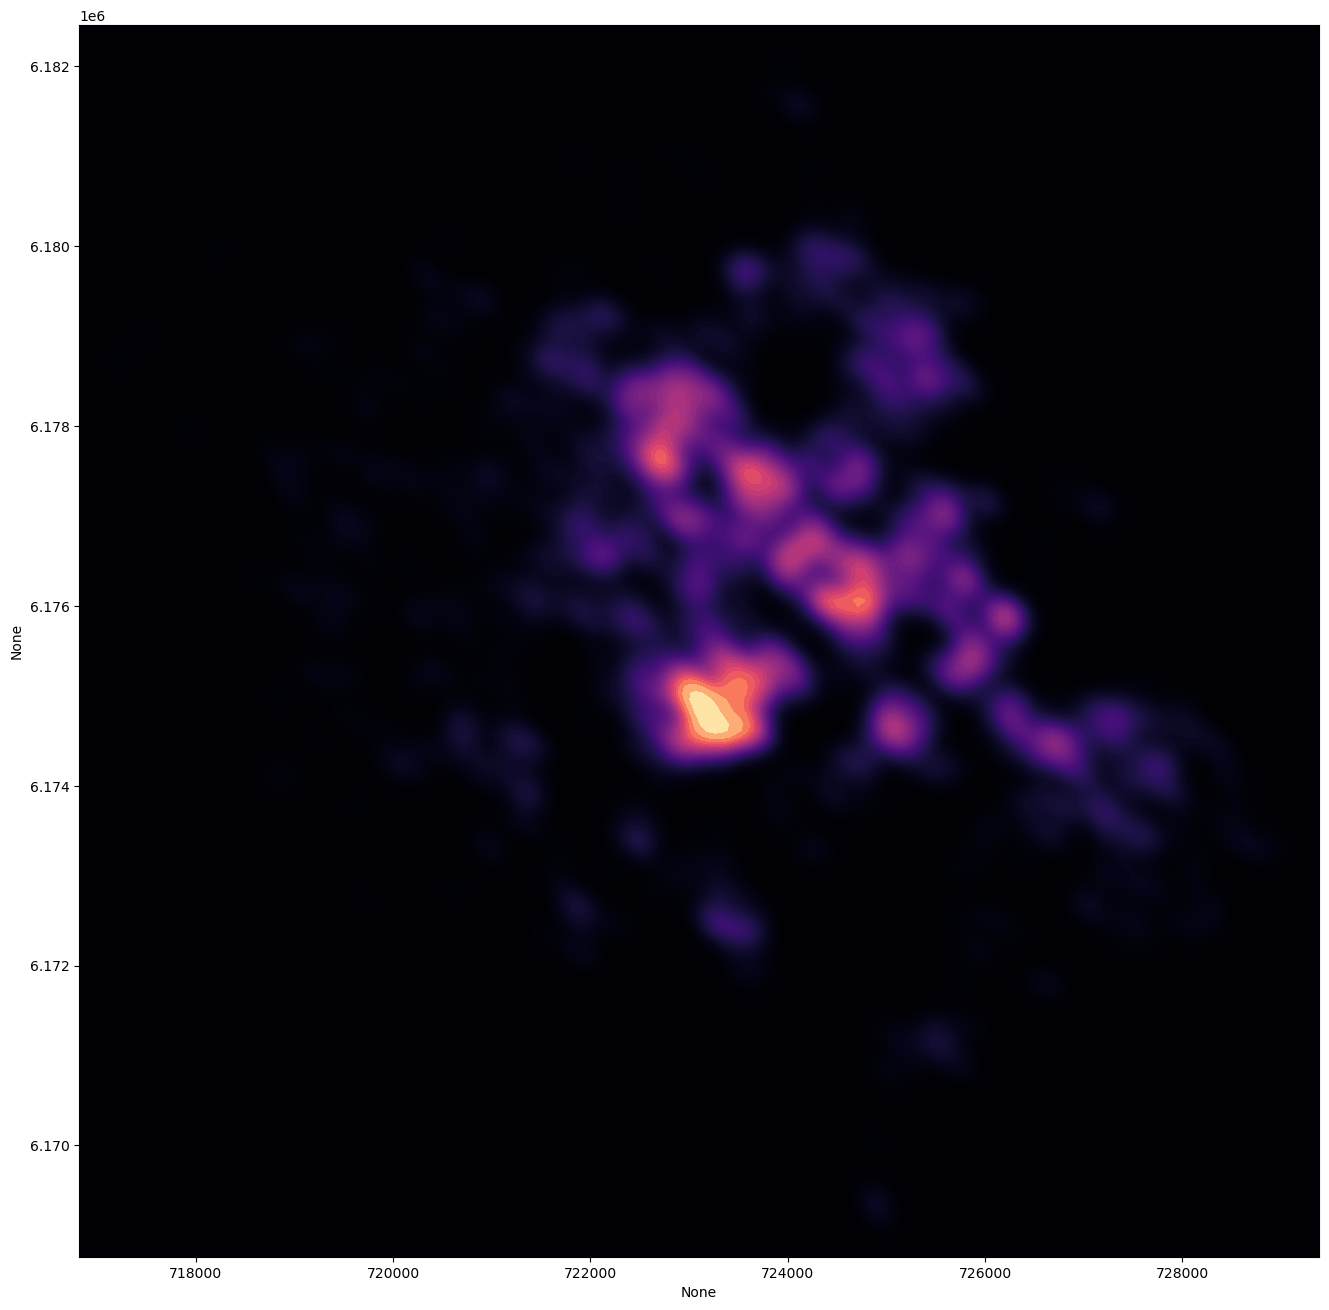

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    x=listings20.geometry.x,
    y=listings20.geometry.y,
    fill=True,
    thresh=0,
    levels=50,
    cmap="magma",
    bw_adjust=0.3
)

plt.show()

Play around with the ```bw_adjust``` parameter!

We can also plot the KDE together with other layers for context:

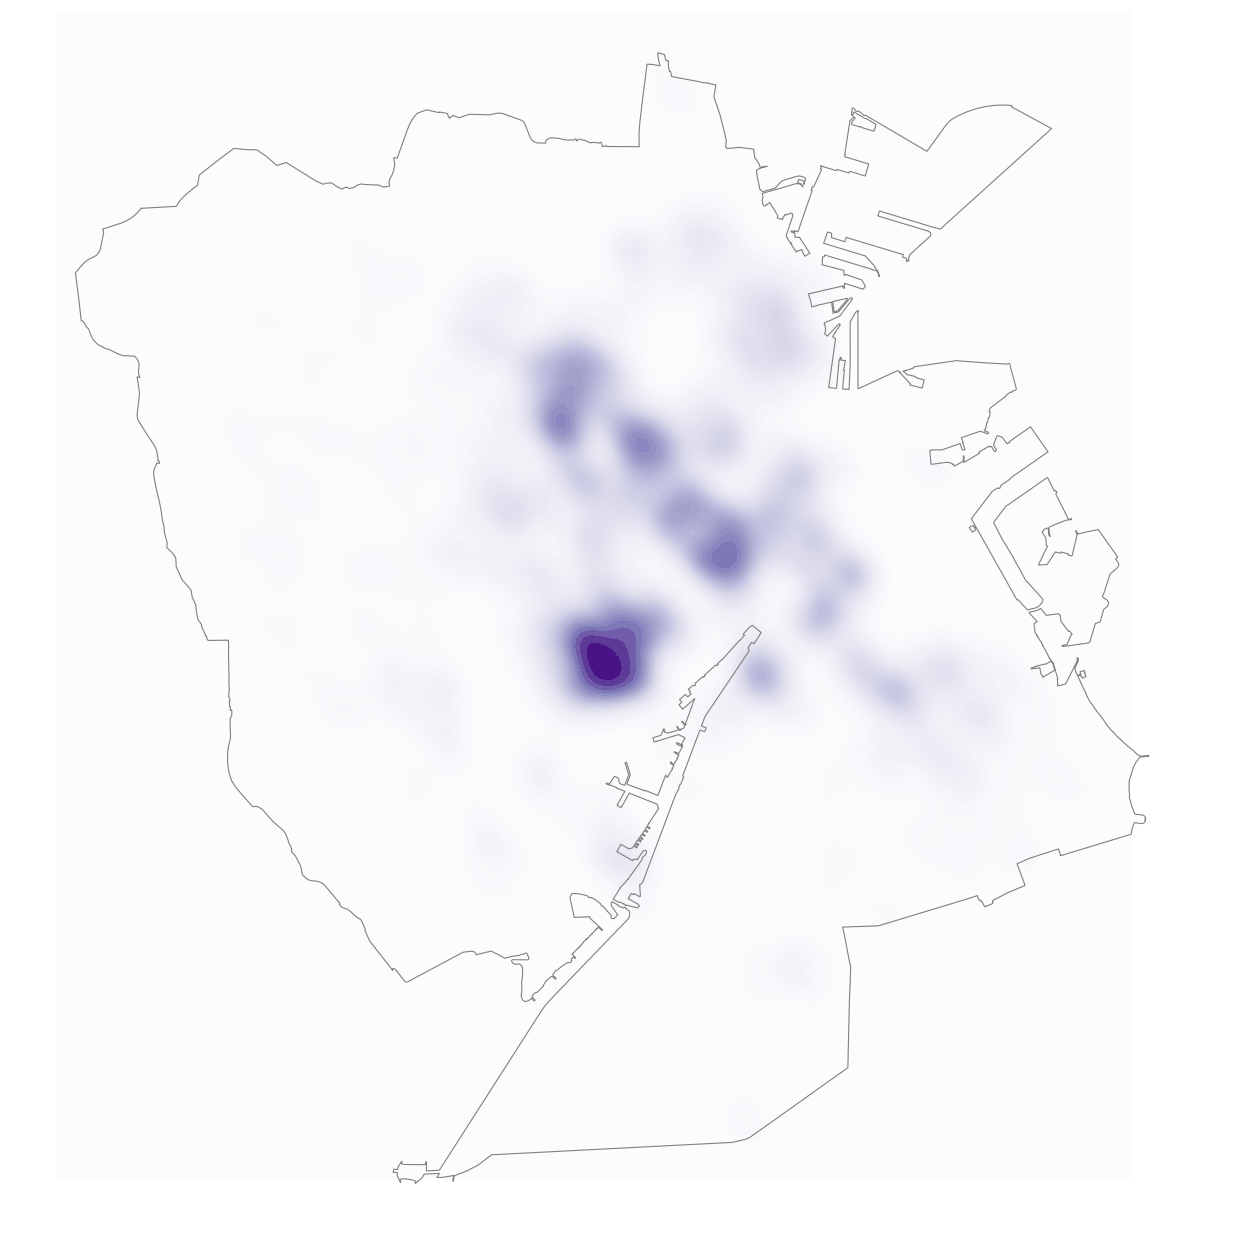

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(16, 16))

sns.kdeplot(
    x=listings20.geometry.x,
    y=listings20.geometry.y,
    fill=True,              # replaces shade=True
    thresh=0,
    levels=50,
    cmap="Purples",
    bw_adjust=0.4,
    ax=ax
)

# Overlay Copenhagen boundary
cph.plot(edgecolor='grey', color="none", linewidth=0.8, ax=ax)

# Clean up axes
ax.set_axis_off()
plt.axis('equal')
plt.show()

### Average nearest neighbor distance

Run the following block a couple of times. What happens here?

In [73]:
Do = pp_20.mean_nnd # calculate the observed mean nearest neighbor distance nnd (Do) for the point pattern
De = csr(pp_20.window, pp_20.n, 1, asPP=True).realizations[0].mean_nnd # calculate the expected mean nearest neighbor 
            # distance (De) for the point pattern pp_20. Use a random process (Poisson point process with the same 
            # intensity and window as pp_20) to estimate the expected mean NND. 
        
        # This line is used to compare the observed pattern to a random or CSR (Complete Spatial Randomness) pattern.

print('NND =', str(Do), '/', str(De), '=', str(Do/De)) # print the results

NND = 54.93704735691016 / 94.5831883444708 = 0.5808331091232632


### K function

The blue line is our point pattern, the orange line is CSR. How do we interpret this?  You might have aproblem with K-function, therefore in stall via your terminal following: 

conda create -n ppa_legacy -c conda-forge python=3.9 pointpats=2.2.0 pysal=2.1.0
conda activate ppa_legacy

pp_20_k = K(pp_20) # calculates the K-function for the point pattern
pp_20_k.plot() # plot K-function results

In [90]:
pip install pointpats==2.2.0

Note: you may need to restart the kernel to use updated packages.


In [91]:
import pointpats, pointpats.distance_statistics as dst
print("pointpats:", pointpats.__version__, "Has K?", hasattr(dst, "K"))

pp_20_k = dst.K(pp_20)      # use dst.K, not a stale 'K' variable
pp_20_k.plot()

pointpats: 2.3.0 Has K? False


AttributeError: module 'pointpats.distance_statistics' has no attribute 'K'

Let's make a little fake regular point pattern and look at its K-function:

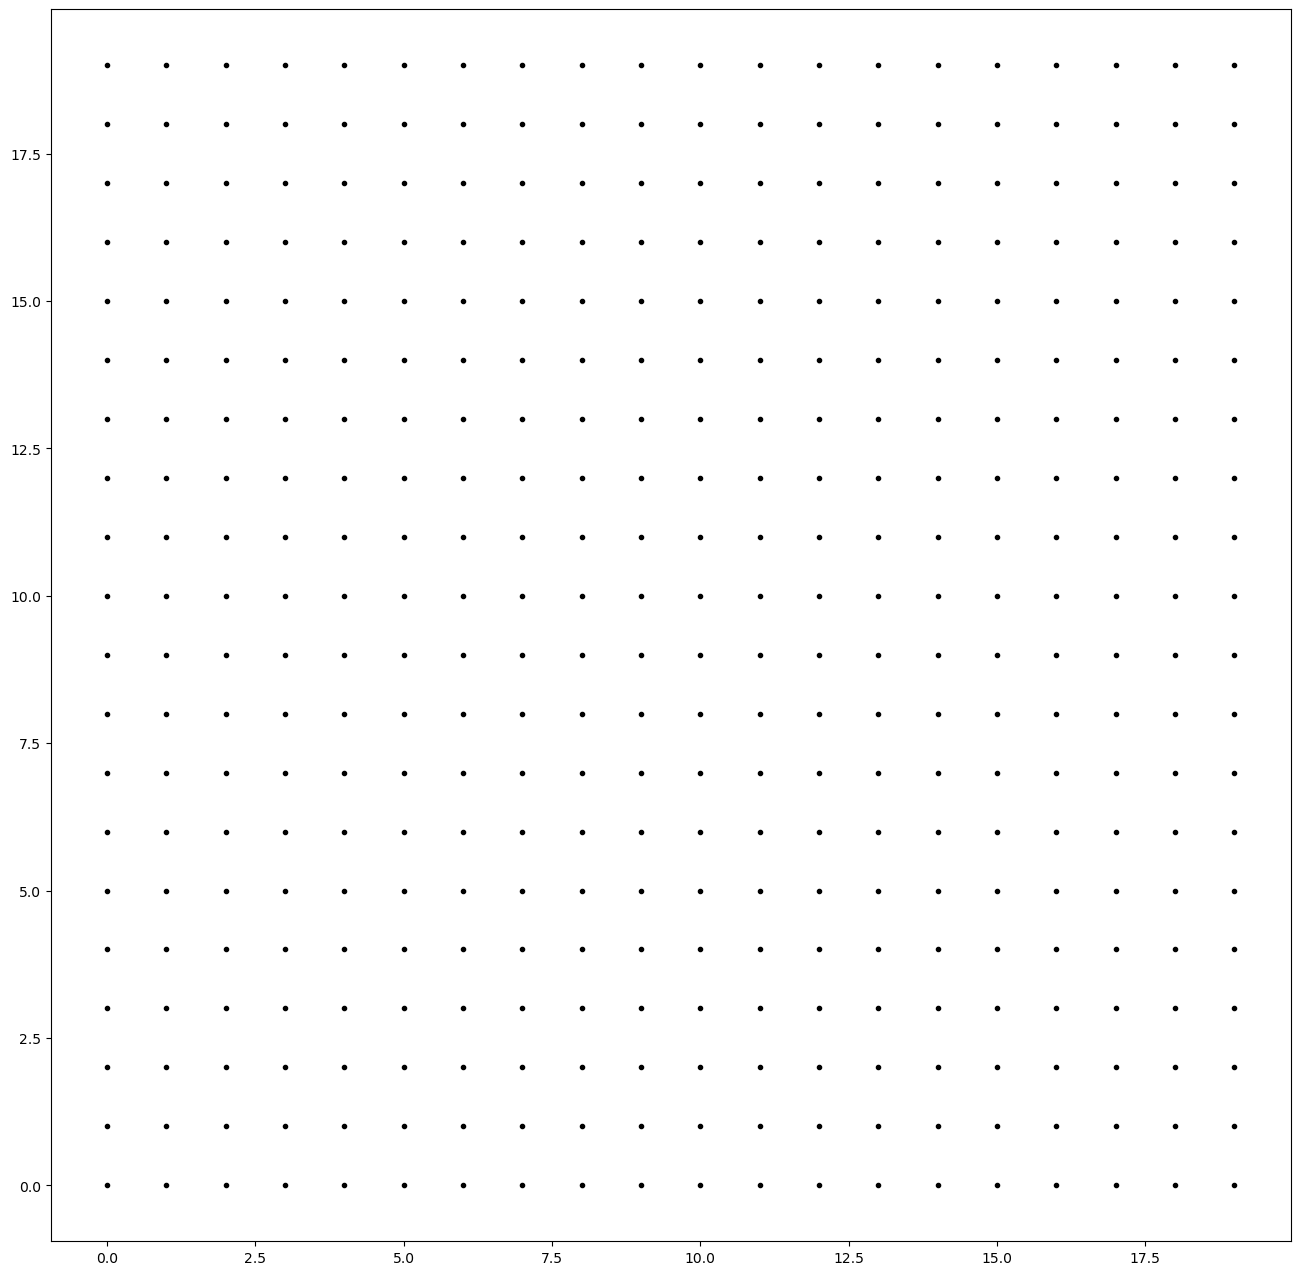

In [82]:
xx, yy = np.meshgrid(np.arange(20), np.arange(20)) # we use NumPy to generate a grid of points along x 
                                                    # and y axes between bellow range 20 (np.arange(20)
plt.plot(xx, yy, marker='.', color='k', linestyle='none') # using Matplotlib we display / plot scatterplot with 
                                                            # k'/black-colored dots/markers, and ignore line-style

In [83]:
reg_pattern = PointPattern(np.array([event for event in zip(xx.flatten(),yy.flatten())])) # using the point pattrns 
                                    # crate x, y coordinates array, flatten tem and zipp together
K(reg_pattern).plot() # calculate and plot the K-function

TypeError: 'NoneType' object is not callable

Simulation envelopes (this takes a while...)

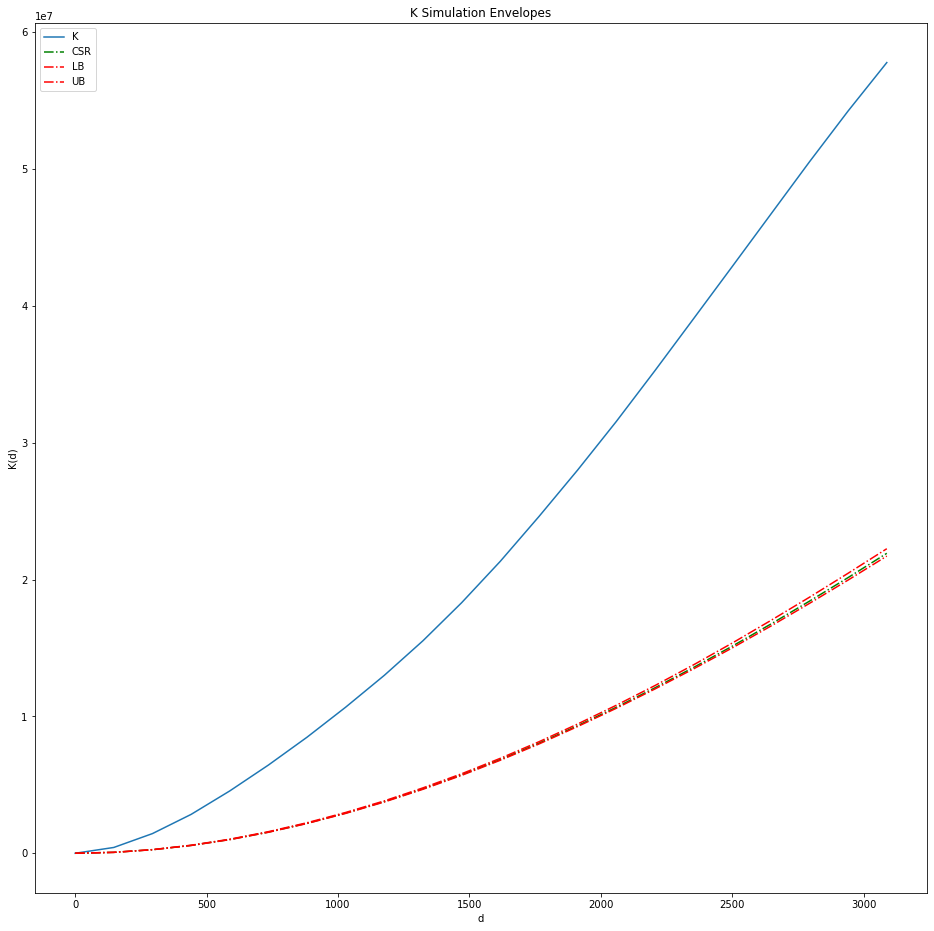

In [48]:
kenv = Kenv(pp_20, intervals=20, realizations=csr_process) # calculate K-function envelope for pp_20s. 
                                            # perform statistical summary of the point pattern's spatial distribution, 
                                            # and assess whether patterns are clustered or dispersed.
kenv.plot() # plot the results

In [ ]:
# The end :)